In [42]:
# ============================================================
# USER MODEL SELECTION CELL
# Change only the selected_example line below.
# Do not change anything else in this cell unless you want to
# add more example files later.
# ============================================================

EXAMPLE_MODELS = {
    "truss_example_for_user": "inputs/user_examples/truss_example_for_user.json",
    "beam_example_for_user": "inputs/user_examples/beam_example_for_user.json",
}

selected_example = "truss_example_for_user"

model_path = EXAMPLE_MODELS[selected_example]

print("Selected example")
print(selected_example)
print()
print("Model path")
print(model_path)

Selected example
truss_example_for_user

Model path
inputs/user_examples/truss_example_for_user.json


In [43]:
import importlib
from pathlib import Path
from IPython.display import display

try:
    import helpers.elements_3d as e3d
    import helpers.preprocess as prep
    import helpers.postprocess as post
    import helpers.solver as solv
    import helpers.output_writer as ow
    import helpers.plotting_simple as ps
    import helpers.plotting_plotly as pp3d

    importlib.reload(e3d)
    importlib.reload(prep)
    importlib.reload(post)
    importlib.reload(solv)
    importlib.reload(ow)
    importlib.reload(ps)
    importlib.reload(pp3d)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.output_writer import write_run_outputs
    from helpers.plotting_simple import plot_structure_simple
    from helpers.plotting_plotly import plot_structure_plotly

except ImportError:
    import elements_3d as e3d
    import preprocess as prep
    import postprocess as post
    import solver as solv
    import output_writer as ow
    import plotting_simple as ps
    import plotting_plotly as pp3d

    importlib.reload(e3d)
    importlib.reload(prep)
    importlib.reload(post)
    importlib.reload(solv)
    importlib.reload(ow)
    importlib.reload(ps)
    importlib.reload(pp3d)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from output_writer import write_run_outputs
    from plotting_simple import plot_structure_simple
    from plotting_plotly import plot_structure_plotly

In [44]:
# ============================================================
# MAIN RUN CELL
# This cell
# 1. reads the JSON file
# 2. preprocesses the model
# 3. solves the model
# 4. saves the standard output tables
# ============================================================

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

output_dir, tables, global_summary, dof_summary = write_run_outputs(
    clean_model=clean_model,
    data=data,
    summary=summary,
    package=package,
    model_path=model_path,
    output_root="outputs/runs"
)

print("Model ran successfully")
print()
print("Model name")
print(clean_model["model_name"])
print()
print("Total DOF")
print(data["ndof"])
print()
print("Outputs saved to")
print(output_dir)
print()
print("Available tables")
print(list(tables.keys()))

Model ran successfully

Model name
truss_example_for_user

Total DOF
108

Outputs saved to
outputs\runs\truss_example_for_user

Available tables
['model_summary', 'nodal_loads', 'node_displacements', 'support_reactions', 'element_basic_data', 'element_local_displacements', 'element_local_end_forces', 'element_global_end_forces', 'element_derived_results']


In [45]:
# ============================================================
# QUICK NOTEBOOK TABLES
# These are the main tables most users will want to inspect.
# ============================================================

display(tables["model_summary"])
display(tables["node_displacements"])
display(tables["support_reactions"])
display(tables["element_local_end_forces"])
display(tables["element_derived_results"])

,model_name,length_unit,force_unit,n_nodes,n_elements,n_truss_elements,n_frame_elements,n_free_dofs,n_restrained_dofs,max_displacement_node,max_displacement_magnitude
0,truss_example_for_user,mm,kN,18,53,53,0,48,60,18,6.871995


,node_id,x,y,z,ux,uy,uz,rx,ry,rz,disp_mag,rot_mag
0,1,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
1,2,1000.0,0.0,0.0,0.269501,-0.055594,-0.239440,0.0,0.0,0.0,0.364765,0.0
2,3,2000.0,0.0,0.0,0.464240,0.000000,0.000000,0.0,0.0,0.0,0.464240,0.0
3,4,0.0,1000.0,0.0,-0.136657,0.175751,-0.143832,0.0,0.0,0.0,0.265049,0.0
4,5,1000.0,1000.0,0.0,-0.069496,-0.004047,-2.040045,0.0,0.0,0.0,2.041232,0.0
5,6,2000.0,1000.0,0.0,0.050762,-0.031250,-3.518065,0.0,0.0,0.0,3.518570,0.0
6,7,0.0,2000.0,0.0,-0.332124,0.322750,0.000000,0.0,0.0,0.0,0.463113,0.0
7,8,1000.0,2000.0,0.0,-0.332124,0.117942,-3.437425,0.0,0.0,0.0,3.455446,0.0
8,9,2000.0,2000.0,0.0,-0.292811,0.007187,-5.910714,0.0,0.0,0.0,5.917967,0.0
9,10,0.0,0.0,1200.0,2.075090,1.634902,0.462857,0.0,0.0,0.0,2.682003,0.0


,node_id,x,y,z,Rx,Ry,Rz,Mx,My,Mz,reaction_force_mag,reaction_moment_mag
0,1,0.0,0.0,0.0,-60.0,-37.5,-54.0,0.0,0.0,0.0,89.007022,0.0
1,2,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,3,2000.0,0.0,0.0,0.0,7.5,101.0,0.0,0.0,0.0,101.278083,0.0
3,4,0.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
4,5,1000.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
5,6,2000.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
6,7,0.0,2000.0,0.0,0.0,0.0,83.0,0.0,0.0,0.0,83.000000,0.0
7,8,1000.0,2000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
8,9,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
9,10,0.0,0.0,1200.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


,elem_id,type,node_i,node_j,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local
0,1,3D_truss,1,2,-6.468027e+01,0.0,0.0,0.0,0.0,0.0,6.468027e+01,0.0,0.0,0.0,0.0,0.0
1,2,3D_truss,2,3,-4.673724e+01,0.0,0.0,0.0,0.0,0.0,4.673724e+01,0.0,0.0,0.0,0.0,0.0
2,3,3D_truss,4,5,-1.611844e+01,0.0,0.0,0.0,0.0,0.0,1.611844e+01,0.0,0.0,0.0,0.0,0.0
3,4,3D_truss,5,6,-2.886212e+01,0.0,0.0,0.0,0.0,0.0,2.886212e+01,0.0,0.0,0.0,0.0,0.0
4,5,3D_truss,7,8,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0
5,6,3D_truss,8,9,-9.435266e+00,0.0,0.0,0.0,0.0,0.0,9.435266e+00,0.0,0.0,0.0,0.0,0.0
6,7,3D_truss,1,4,-4.218027e+01,0.0,0.0,0.0,0.0,0.0,4.218027e+01,0.0,0.0,0.0,0.0,0.0
7,8,3D_truss,4,7,-3.527962e+01,0.0,0.0,0.0,0.0,0.0,3.527962e+01,0.0,0.0,0.0,0.0,0.0
8,9,3D_truss,2,5,-1.237123e+01,0.0,0.0,0.0,0.0,0.0,1.237123e+01,0.0,0.0,0.0,0.0,0.0
9,10,3D_truss,5,8,-2.927735e+01,0.0,0.0,0.0,0.0,0.0,2.927735e+01,0.0,0.0,0.0,0.0,0.0


,elem_id,type,node_i,node_j,L,axial_i_local,axial_j_local,axial_abs_max,shear_y_abs_max,shear_z_abs_max,torsion_abs_max,moment_y_abs_max,moment_z_abs_max,moment_abs_max,stress_axial_i,stress_axial_j,stress_axial_abs_max
0,1,3D_truss,1,2,1000.000000,-6.468027e+01,6.468027e+01,6.468027e+01,0.0,0.0,0.0,0.0,0.0,0.0,-5.390022e-02,5.390022e-02,5.390022e-02
1,2,3D_truss,2,3,1000.000000,-4.673724e+01,4.673724e+01,4.673724e+01,0.0,0.0,0.0,0.0,0.0,0.0,-3.894770e-02,3.894770e-02,3.894770e-02
2,3,3D_truss,4,5,1000.000000,-1.611844e+01,1.611844e+01,1.611844e+01,0.0,0.0,0.0,0.0,0.0,0.0,-1.343204e-02,1.343204e-02,1.343204e-02
3,4,3D_truss,5,6,1000.000000,-2.886212e+01,2.886212e+01,2.886212e+01,0.0,0.0,0.0,0.0,0.0,0.0,-2.405176e-02,2.405176e-02,2.405176e-02
4,5,3D_truss,7,8,1000.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00
5,6,3D_truss,8,9,1000.000000,-9.435266e+00,9.435266e+00,9.435266e+00,0.0,0.0,0.0,0.0,0.0,0.0,-7.862722e-03,7.862722e-03,7.862722e-03
6,7,3D_truss,1,4,1000.000000,-4.218027e+01,4.218027e+01,4.218027e+01,0.0,0.0,0.0,0.0,0.0,0.0,-3.515022e-02,3.515022e-02,3.515022e-02
7,8,3D_truss,4,7,1000.000000,-3.527962e+01,3.527962e+01,3.527962e+01,0.0,0.0,0.0,0.0,0.0,0.0,-2.939969e-02,2.939969e-02,2.939969e-02
8,9,3D_truss,2,5,1000.000000,-1.237123e+01,1.237123e+01,1.237123e+01,0.0,0.0,0.0,0.0,0.0,0.0,-1.030936e-02,1.030936e-02,1.030936e-02
9,10,3D_truss,5,8,1000.000000,-2.927735e+01,2.927735e+01,2.927735e+01,0.0,0.0,0.0,0.0,0.0,0.0,-2.439779e-02,2.439779e-02,2.439779e-02


In [46]:
# ============================================================
# PLOT SAVE LOCATIONS
# Simple plots go to outputs/user_examples/simple_plots
# Plotly plots go to outputs/user_examples/plotly_plots
# File names are based on the model name.
# ============================================================

plot_dir_simple = Path("outputs/user_examples/simple_plots")
plot_dir_plotly = Path("outputs/user_examples/plotly_plots")

plot_dir_simple.mkdir(parents=True, exist_ok=True)
plot_dir_plotly.mkdir(parents=True, exist_ok=True)

simple_undeformed = plot_dir_simple / f"{clean_model['model_name']}_undeformed.png"
simple_def_undef = plot_dir_simple / f"{clean_model['model_name']}_undeformed_plus_deformed.png"

plotly_undef_html = plot_dir_plotly / f"{clean_model['model_name']}_undeformed.html"
plotly_undef_png = plot_dir_plotly / f"{clean_model['model_name']}_undeformed.png"

plotly_def_html = plot_dir_plotly / f"{clean_model['model_name']}_undeformed_plus_deformed.html"
plotly_def_png = plot_dir_plotly / f"{clean_model['model_name']}_undeformed_plus_deformed.png"

print("Simple plot folder")
print(plot_dir_simple)
print()
print("Plotly plot folder")
print(plot_dir_plotly)

Simple plot folder
outputs\user_examples\simple_plots

Plotly plot folder
outputs\user_examples\plotly_plots


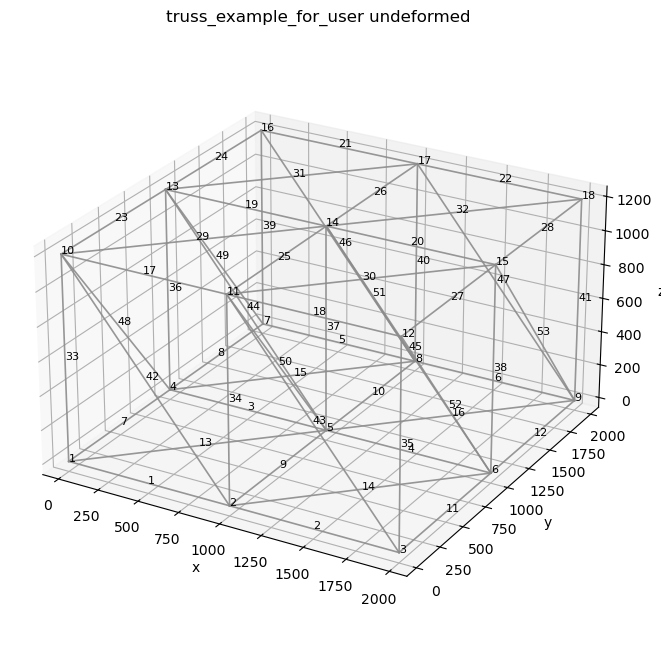

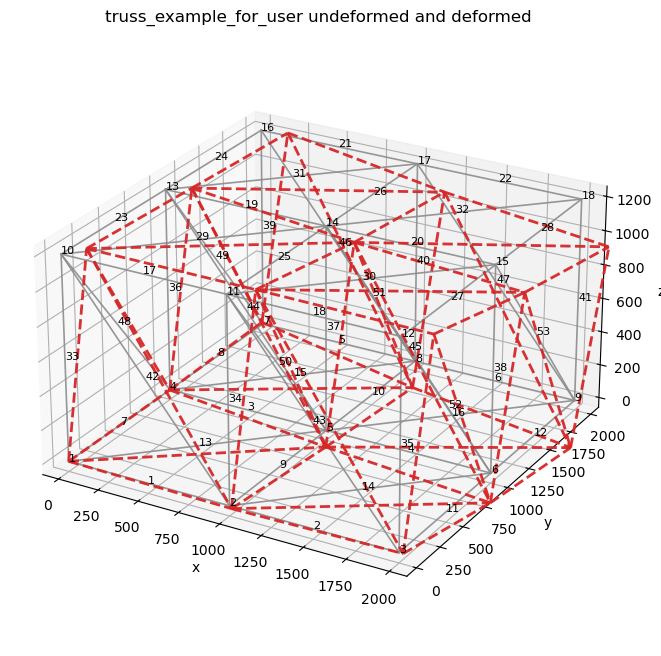

Saved simple plots
outputs\user_examples\simple_plots\truss_example_for_user_undeformed.png
outputs\user_examples\simple_plots\truss_example_for_user_undeformed_plus_deformed.png


In [47]:
# ============================================================
# SIMPLE PLOTS
# Plot 1  undeformed only
# Plot 2  undeformed plus deformed
# Loads are not shown in these plots.
# ============================================================

_ = plot_structure_simple(
    clean_model,
    data,
    U=None,
    scale=1.0,
    selector="all",
    show_undeformed=True,
    show_deformed=False,
    show_node_labels=True,
    show_element_labels=True,
    title=f"{clean_model['model_name']} undeformed",
    save_path=str(simple_undeformed),
)

_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=50.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=True,
    show_element_labels=True,
    title=f"{clean_model['model_name']} undeformed and deformed",
    save_path=str(simple_def_undef),
)

print("Saved simple plots")
print(simple_undeformed)
print(simple_def_undef)

In [48]:
# ============================================================
# PLOTLY PLOTS
# Plot 1  undeformed only
# Plot 2  undeformed plus deformed
# Loads are kept off here because show_member_loads is False.
# ============================================================

fig_undef = plot_structure_plotly(
    clean_model,
    data,
    U=None,
    scale=1.0,
    selector="all",
    show_undeformed=True,
    show_deformed=False,
    show_nodes=True,
    show_node_labels=True,
    show_element_hover=True,
    show_member_loads=True,
    title=f"{clean_model['model_name']} undeformed",
    save_html=str(plotly_undef_html),
    save_png=str(plotly_undef_png),
)

fig_def = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=50.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=True,
    show_node_labels=True,
    show_element_hover=True,
    show_member_loads=True,
    title=f"{clean_model['model_name']} undeformed and deformed",
    save_html=str(plotly_def_html),
    save_png=str(plotly_def_png),
)

fig_undef.show()
fig_def.show()

print("Saved Plotly plots")
print(plotly_undef_html)
print(plotly_undef_png)
print(plotly_def_html)
print(plotly_def_png)

Saved Plotly plots
outputs\user_examples\plotly_plots\truss_example_for_user_undeformed.html
outputs\user_examples\plotly_plots\truss_example_for_user_undeformed.png
outputs\user_examples\plotly_plots\truss_example_for_user_undeformed_plus_deformed.html
outputs\user_examples\plotly_plots\truss_example_for_user_undeformed_plus_deformed.png


In [49]:
# ============================================================
# QUICK USER SUMMARIES
# These are useful if the user wants the main values quickly.
# ============================================================

import pandas as pd

df_nodes = tables["node_displacements"].copy()
df_react = tables["support_reactions"].copy()
df_local = tables["element_local_end_forces"].copy()
df_derived = tables["element_derived_results"].copy()

if "disp_mag" in df_nodes.columns:
    df_max_disp = df_nodes.sort_values("disp_mag", ascending=False).head(10)
else:
    df_nodes["disp_mag_calc"] = (df_nodes["ux"]**2 + df_nodes["uy"]**2 + df_nodes["uz"]**2) ** 0.5
    df_max_disp = df_nodes.sort_values("disp_mag_calc", ascending=False).head(10)

print("Largest displacement rows")
display(df_max_disp)

print("Support reactions")
display(df_react)

if "type" in df_local.columns and "3D_frame" in df_local["type"].astype(str).unique():
    df_frame = df_local[df_local["type"] == "3D_frame"].copy()
    needed = ["Mx_i_local", "My_i_local", "Mz_i_local", "Mx_j_local", "My_j_local", "Mz_j_local"]
    if all(col in df_frame.columns for col in needed):
        df_frame["max_abs_end_moment"] = df_frame[needed].abs().max(axis=1)
        print("Top frame members by end moment")
        display(df_frame.sort_values("max_abs_end_moment", ascending=False).head(10))

if "axial_force" in df_derived.columns:
    df_truss = df_derived[df_derived["type"] == "3D_truss"].copy()
    df_truss["abs_axial"] = df_truss["axial_force"].abs()
    print("Top truss members by axial force")
    display(df_truss.sort_values("abs_axial", ascending=False).head(10))

Largest displacement rows


,node_id,x,y,z,ux,uy,uz,rx,ry,rz,disp_mag,rot_mag
17,18,2000.0,2000.0,1200.0,2.288975,2.455147,-5.996429,0.0,0.0,0.0,6.871995,0.0
8,9,2000.0,2000.0,0.0,-0.292811,0.007187,-5.910714,0.0,0.0,0.0,5.917967,0.0
14,15,2000.0,1000.0,1200.0,2.118640,2.587100,-3.647718,0.0,0.0,0.0,4.948492,0.0
16,17,1000.0,2000.0,1200.0,2.393151,1.948516,-3.564914,0.0,0.0,0.0,4.715135,0.0
13,14,1000.0,1000.0,1200.0,2.199842,2.064424,-2.163647,0.0,0.0,0.0,3.712482,0.0
11,12,2000.0,0.0,1200.0,2.091085,2.804301,-0.384988,0.0,0.0,0.0,3.519226,0.0
5,6,2000.0,1000.0,0.0,0.050762,-0.031250,-3.518065,0.0,0.0,0.0,3.518570,0.0
7,8,1000.0,2000.0,0.0,-0.332124,0.117942,-3.437425,0.0,0.0,0.0,3.455446,0.0
10,11,1000.0,0.0,1200.0,2.035529,2.273902,0.072363,0.0,0.0,0.0,3.052744,0.0
15,16,0.0,2000.0,1200.0,2.562893,1.554813,-0.348552,0.0,0.0,0.0,3.017839,0.0


Support reactions


,node_id,x,y,z,Rx,Ry,Rz,Mx,My,Mz,reaction_force_mag,reaction_moment_mag
0,1,0.0,0.0,0.0,-60.0,-37.5,-54.0,0.0,0.0,0.0,89.007022,0.0
1,2,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,3,2000.0,0.0,0.0,0.0,7.5,101.0,0.0,0.0,0.0,101.278083,0.0
3,4,0.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
4,5,1000.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
5,6,2000.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
6,7,0.0,2000.0,0.0,0.0,0.0,83.0,0.0,0.0,0.0,83.000000,0.0
7,8,1000.0,2000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
8,9,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
9,10,0.0,0.0,1200.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


In [50]:
# ============================================================
# SHOW WHERE EVERYTHING WAS SAVED
# ============================================================

print("Run output files")
for p in sorted(Path(output_dir).iterdir()):
    print(p.name)

print()
print("Simple plot files")
for p in sorted(plot_dir_simple.iterdir()):
    if clean_model["model_name"] in p.name:
        print(p.name)

print()
print("Plotly plot files")
for p in sorted(plot_dir_plotly.iterdir()):
    if clean_model["model_name"] in p.name:
        print(p.name)

Run output files
dof_summary.json
element_basic_data.csv
element_derived_results.csv
element_global_end_forces.csv
element_local_displacements.csv
element_local_end_forces.csv
global_summary.json
nodal_loads.csv
node_displacements.csv
run_log.txt
summary.md
support_reactions.csv

Simple plot files
truss_example_for_user_undeformed.png
truss_example_for_user_undeformed_plus_deformed.png

Plotly plot files
truss_example_for_user_undeformed.html
truss_example_for_user_undeformed.png
truss_example_for_user_undeformed_plus_deformed.html
truss_example_for_user_undeformed_plus_deformed.png
